---
title: Construcción de ResNet-34 con PyTorch
subject: Aprendizaje Profundo
subtitle: 
short_title: ResNet-34
authors:
  - name: Jorge Anais
    orcid: 0000-0001-9051-1338
    email: jrganais@gmail.com
license: MIT
---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jorgeanais/libro_aprendizaje_profundo/blob/main/cap2/080_ResNet34.ipynb)

**Objetivo**: En este cuadernillo implementarás **ResNet-34** desde cero en PyTorch, comprenderás el mecanismo de las conexiones residuales (*skip connections*).

Basado en He y colaboradores (2016) *Deep Residual Learning for Image Recognition* y en Géron (2025) *Hands-On Machine Learning*.

<font color="teal">**Tip**. El entrenamiento con imágenes puede ser lento sin acelerador de hardware. Si estás en Colab, ve a **Entorno de ejecución > Cambiar tipo de entorno de ejecución** y selecciona **GPU T4**.</font>

## 1. Preparativos

Verificamos las versiones de las librerías principales y el dispositivo disponible (CPU o GPU).

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 34.0 MB/s eta 0:00:00


In [2]:
import sys
import torch
import torchvision
import torchmetrics

print(f"Python      : {sys.version}")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print(f"Torchmetrics: {torchmetrics.__version__}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nDispositivo : {device}")
if device.type == "cuda":
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
else:
    print("No se detectó GPU. El entrenamiento usará CPU (más lento).")

Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128
Torchmetrics: 1.9.0

Dispositivo : cuda
GPU         : Tesla T4


## 2. El problema del gradiente que desvanece y la solución residual

A medida que las redes neuronales se hacen más profundas, el entrenamiento se vuelve más difícil: los gradientes se **desvanecen** (o explotan) al propagarse hacia atrás a través de muchas capas. He et al. (2016) propusieron una solución elegante: en lugar de aprender la transformación $\mathcal{H}(\mathbf{x})$ directamente, la red aprende la **función residual** $\mathcal{F}(\mathbf{x}) = \mathcal{H}(\mathbf{x}) - \mathbf{x}$.

La salida del bloque es entonces:

$$\mathcal{H}(\mathbf{x}) = \mathcal{F}(\mathbf{x}) + \mathbf{x}$$

Esto permite que el gradiente fluya directamente hacia atrás a través de la conexión de salto (*skip connection*), mitigando el problema del gradiente que desvanece.

### 2.1 Imports generales

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms.v2 as T
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchmetrics import Accuracy
from functools import partial
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import urllib.request
import zipfile

print("Imports completados.")

Imports completados.


## 3. Implementación del bloque residual (`ResidualUnit`)

El corazón de ResNet es su **bloque residual**. Cada bloque tiene dos caminos:

- **Camino principal**: aplica dos convoluciones con BatchNorm.
- **Conexión de salto**: pasa la entrada directamente (o con una convolución $1\times1$ si las dimensiones cambian).

Ambos caminos se **suman** antes de la activación final ReLU.

In [4]:
class ResidualUnit(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        # Definimos una convolución estándar para evitar repetición de código
        DefaultConv2d = partial(
            nn.Conv2d, kernel_size=3, stride=1, padding=1, bias=False)

        # Camino principal
        self.main_layers = nn.Sequential(
            DefaultConv2d(in_channels, out_channels, stride=stride),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            DefaultConv2d(out_channels, out_channels),
            nn.BatchNorm2d(out_channels),
        )

        # Conexión de salto (skip connection)
        if stride > 1:
            self.skip_connection = nn.Sequential(
                DefaultConv2d(in_channels, out_channels, kernel_size=1,
                              stride=stride, padding=0),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.skip_connection = nn.Identity()

    def forward(self, inputs):
        return F.relu(self.main_layers(inputs) + self.skip_connection(inputs))


print("ResidualUnit definido correctamente.")

ResidualUnit definido correctamente.


## 4. Construcción de la arquitectura ResNet-34

Con `ResidualUnit` como bloque base, construimos la arquitectura completa. ResNet-34 se organiza así:

| Etapa | Bloques residuales | Filtros |
|-------|-------------------|---------|
| Stem (inicio) | Conv7×7 + BN + ReLU + MaxPool | 64 |
| conv2_x | 3 bloques | 64 |
| conv3_x | 4 bloques | 128 |
| conv4_x | 6 bloques | 256 |
| conv5_x | 3 bloques | 512 |
| Cabeza | AvgPool + Flatten + Linear | — |

In [5]:
class ResNet34(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Capas iniciales (Stem)
        layers = [
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=7, stride=2,
                      padding=3, bias=False),
            nn.BatchNorm2d(num_features=64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        ]

        # Construcción dinámica de los bloques residuales
        prev_filters = 64
        for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
            stride = 1 if filters == prev_filters else 2
            layers.append(ResidualUnit(prev_filters, filters, stride=stride))
            prev_filters = filters

        # Capas finales de clasificación
        layers += [
            nn.AdaptiveAvgPool2d(output_size=1),
            nn.Flatten(),
            nn.Linear(512, num_classes),
        ]
        self.resnet = nn.Sequential(*layers)

    def forward(self, inputs):
        return self.resnet(inputs)


# Instanciamos el modelo y lo movemos al dispositivo
model_scratch = ResNet34(num_classes=2).to(device)
print("ResNet-34 desde cero instanciada correctamente.")

ResNet-34 desde cero instanciada correctamente.


### 4.1 Inspección de la arquitectura

Contemos los parámetros entrenables y comparemos con ConvNeXt Base (usado en la actividad anterior).

In [6]:
def count_parameters(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

total, trainable = count_parameters(model_scratch)
print(f"Parámetros totales     : {total:,}")
print(f"Parámetros entrenables : {trainable:,}")
print(f"\nComparación referencial:")
print(f"  ResNet-34 (nuestra)  : ~21.8 M parámetros")
print(f"  ConvNeXt Base        : ~88.6 M parámetros")

Parámetros totales     : 21,285,698
Parámetros entrenables : 21,285,698

Comparación referencial:
  ResNet-34 (nuestra)  : ~21.8 M parámetros
  ConvNeXt Base        : ~88.6 M parámetros


### 4.2 Verificación de la forma de salida

Pasamos un tensor de prueba para verificar que la arquitectura produce la forma correcta.

In [7]:
model_scratch.eval()
dummy_input = torch.zeros(4, 3, 224, 224).to(device)  # batch=4, RGB, 224x224

with torch.no_grad():
    dummy_output = model_scratch(dummy_input)

print(f"Forma de entrada : {dummy_input.shape}")
print(f"Forma de salida  : {dummy_output.shape}")
print(f"\n✓ Correcto: batch=4, num_classes=2")

Forma de entrada : torch.Size([4, 3, 224, 224])
Forma de salida  : torch.Size([4, 2])

✓ Correcto: batch=4, num_classes=2


## 5. Conjunto de datos y pipeline

Usaremos el mismo **dataset Hymenoptera** (hormigas y abejas) de la actividad anterior, con las mismas transformaciones, para poder comparar los resultados directamente.

In [9]:
def download_hymenoptera_dataset():
    data_dir = Path("datasets")
    url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
    zip_path = data_dir / "hymenoptera_data.zip"
    data_dir.mkdir(parents=True, exist_ok=True)
    if not zip_path.exists():
        print("Descargando...", end="")
        urllib.request.urlretrieve(url, zip_path)
        print(" Listo.")
    unzipped_dir = data_dir / "hymenoptera_data"
    if not unzipped_dir.exists():
        print("Extrayendo...", end="")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(data_dir)
        print(" Listo.")
    return unzipped_dir

hymenoptera_dir = download_hymenoptera_dataset()
print(f"\nDataset disponible en: {hymenoptera_dir}")

Descargando... Listo.
Extrayendo... Listo.

Dataset disponible en: datasets/hymenoptera_data


In [10]:
# Transformaciones (idénticas a la actividad de Transfer Learning)
train_transforms = T.Compose([
    T.RandomResizedCrop(224),
    T.RandomHorizontalFlip(),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

valid_test_transforms = T.Compose([
    T.Resize(232),
    T.CenterCrop(224),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_set      = ImageFolder(hymenoptera_dir / "train", train_transforms)
valid_test_set = ImageFolder(hymenoptera_dir / "val",   valid_test_transforms)

torch.manual_seed(42)
valid_set, test_set = torch.utils.data.random_split(valid_test_set, [0.5, 0.5])

class_names = train_set.classes

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_set, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False, num_workers=2)

print(f"Clases            : {class_names}")
print(f"Imágenes train    : {len(train_set)}")
print(f"Imágenes val      : {len(valid_set)}")
print(f"Imágenes test     : {len(test_set)}")

Clases            : ['ants', 'bees']
Imágenes train    : 244
Imágenes val      : 77
Imágenes test     : 76


## 6. Loop de entrenamiento

Definimos funciones reutilizables de entrenamiento y evaluación. A diferencia de la actividad anterior, aquí **todos** los parámetros son entrenables desde la primera época.

In [11]:
def train_one_epoch(model, loader, optimizer, criterion, accuracy_metric):
    model.train()
    accuracy_metric.reset()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(X_batch)
        accuracy_metric.update(logits.argmax(dim=1), y_batch)

    avg_loss = total_loss / len(loader.dataset)
    avg_acc  = accuracy_metric.compute().item()
    return avg_loss, avg_acc


@torch.no_grad()
def evaluate(model, loader, criterion, accuracy_metric):
    model.eval()
    accuracy_metric.reset()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(X_batch)
        accuracy_metric.update(logits.argmax(dim=1), y_batch)

    avg_loss = total_loss / len(loader.dataset)
    avg_acc  = accuracy_metric.compute().item()
    return avg_loss, avg_acc


print("Funciones de entrenamiento definidas.")

Funciones de entrenamiento definidas.


## 7. Entrenamiento de la ResNet-34 desde cero

Entrenamos el modelo completo con todos sus parámetros libres. Usamos:
- **Optimizador**: SGD con momentum (como en el paper original)
- **Learning rate**: `1e-2` con decay por `StepLR`
- **Épocas**: 20

In [12]:
# Re-instanciamos el modelo para asegurar pesos aleatorios
torch.manual_seed(42)
model_scratch = ResNet34(num_classes=2).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model_scratch.parameters(), lr=1e-2,
                            momentum=0.9, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)
accuracy  = Accuracy(task="multiclass", num_classes=2).to(device)

n_epochs = 20
history  = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"Entrenando ResNet-34 desde cero por {n_epochs} épocas...\n")
print(f"{'Época':>5} {'Train Loss':>12} {'Train Acc':>11} {'Val Loss':>10} {'Val Acc':>9}")
print("-" * 55)

for epoch in range(1, n_epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model_scratch, train_loader,
                                      optimizer, criterion, accuracy)
    va_loss, va_acc = evaluate(model_scratch, valid_loader, criterion, accuracy)
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    print(f"{epoch:>5} {tr_loss:>12.4f} {tr_acc:>11.4f} {va_loss:>10.4f} {va_acc:>9.4f}")

print("\nEntrenamiento completado.")

Entrenando ResNet-34 desde cero por 20 épocas...

Época   Train Loss   Train Acc   Val Loss   Val Acc
-------------------------------------------------------
    1       0.9719      0.5205     0.9397    0.4675
    2       1.2562      0.5246    19.1307    0.4545
    3       0.8295      0.5697     8.0632    0.5325
    4       0.8462      0.5902   238.7899    0.4675
    5       0.8121      0.5779    55.9713    0.5195
    6       0.8928      0.5492     1.5301    0.5195
    7       0.7114      0.5410     4.7112    0.4545
    8       0.7252      0.5902     0.6082    0.6623
    9       0.6748      0.6270     0.6005    0.6104
   10       0.6577      0.6557     0.6642    0.5584
   11       0.6357      0.6557     0.5994    0.7143
   12       0.6475      0.6393     0.6056    0.6753
   13       0.6367      0.6557     0.5893    0.7143
   14       0.6116      0.6680     0.5987    0.7013
   15       0.6092      0.6762     0.5986    0.6753
   16       0.6180      0.6926     0.5971    0.6753
   17     

## 8. Curvas de aprendizaje

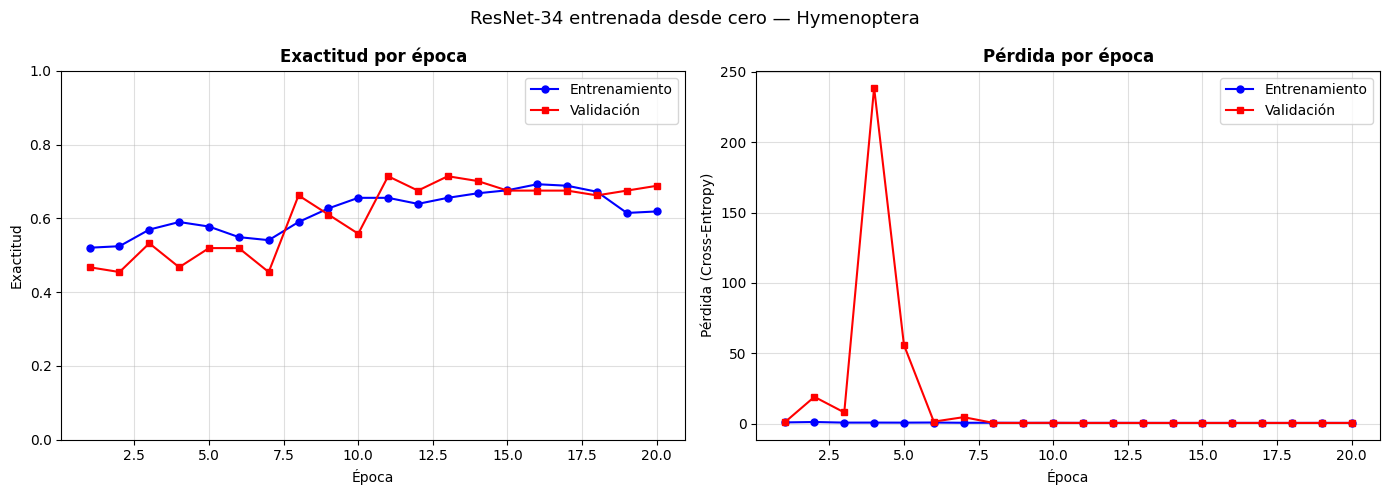

In [13]:
epochs = list(range(1, n_epochs + 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exactitud
axes[0].plot(epochs, history["train_acc"], "bo-", label="Entrenamiento", markersize=5)
axes[0].plot(epochs, history["val_acc"],   "rs-", label="Validación",    markersize=5)
axes[0].set_title("Exactitud por época", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Exactitud")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].grid(alpha=0.4)

# Pérdida
axes[1].plot(epochs, history["train_loss"], "bo-", label="Entrenamiento", markersize=5)
axes[1].plot(epochs, history["val_loss"],   "rs-", label="Validación",    markersize=5)
axes[1].set_title("Pérdida por época", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Pérdida (Cross-Entropy)")
axes[1].legend()
axes[1].grid(alpha=0.4)

plt.suptitle("ResNet-34 entrenada desde cero — Hymenoptera", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Evaluación final en el conjunto de prueba

In [14]:
test_loss, test_acc = evaluate(model_scratch, test_loader, criterion, accuracy)
print(f"Evaluación final — conjunto de prueba:")
print(f"  Pérdida   : {test_loss:.4f}")
print(f"  Exactitud : {test_acc:.4f} ({test_acc*100:.1f}%)")

Evaluación final — conjunto de prueba:
  Pérdida   : 0.5793
  Exactitud : 0.7237 (72.4%)


---

### <font color="blue">**Ejercicio 1.** Análisis del entrenamiento desde cero</font>

Observa las curvas de aprendizaje y los resultados obtenidos:

<font color="green">1. ¿Qué comportamiento observas entre las curvas de entrenamiento y validación? ¿El modelo muestra indicios de sobreajuste (*overfitting*)? Justifica tu respuesta con base en las curvas.</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Las curvas pueden mostrar dos comportamientos distintos dependiendo del entorno de ejecución:


(A) Sobreajuste clásico: la exactitud de entrenamiento sube consistentemente hacia valores altos (>90%) mientras que la de validación se estanca o fluctúa en torno al 60–70%, generando una brecha creciente entre ambas curvas. Este es el resultado teóricamente esperado: con ~245 imágenes y ~21.8 M de parámetros, la red tiene capacidad más que suficiente para memorizar el entrenamiento sin generalizar.   


(B) Inestabilidad por learning rate: la pérdida de entrenamiento colapsa a valores cercanos a cero desde las primeras épocas, pero la pérdida de validación sufre un aumento explosivo (valores >100) antes de estabilizarse. La exactitud de ambos conjuntos se mantiene baja (60–70%) sin una brecha clara entre ellas. Esto indica que el lr inicial de 1e-2 es demasiado agresivo para un dataset tan pequeño: el modelo memoriza el entrenamiento rápidamente pero las actualizaciones de pesos destruyen la capacidad de generalización.


En ambos casos, el resultado final (~60–70% de exactitud) es mediocre para una clasificación binaria, lo que evidencia la limitación fundamental de entrenar desde cero con datos escasos.
</p>
</details>


## 10. Visualización de las activaciones intermedias

Una forma poderosa de entender qué aprende la red es visualizar los **mapas de activación** de distintas capas. Usamos hooks de PyTorch para capturar las activaciones sin modificar el modelo.

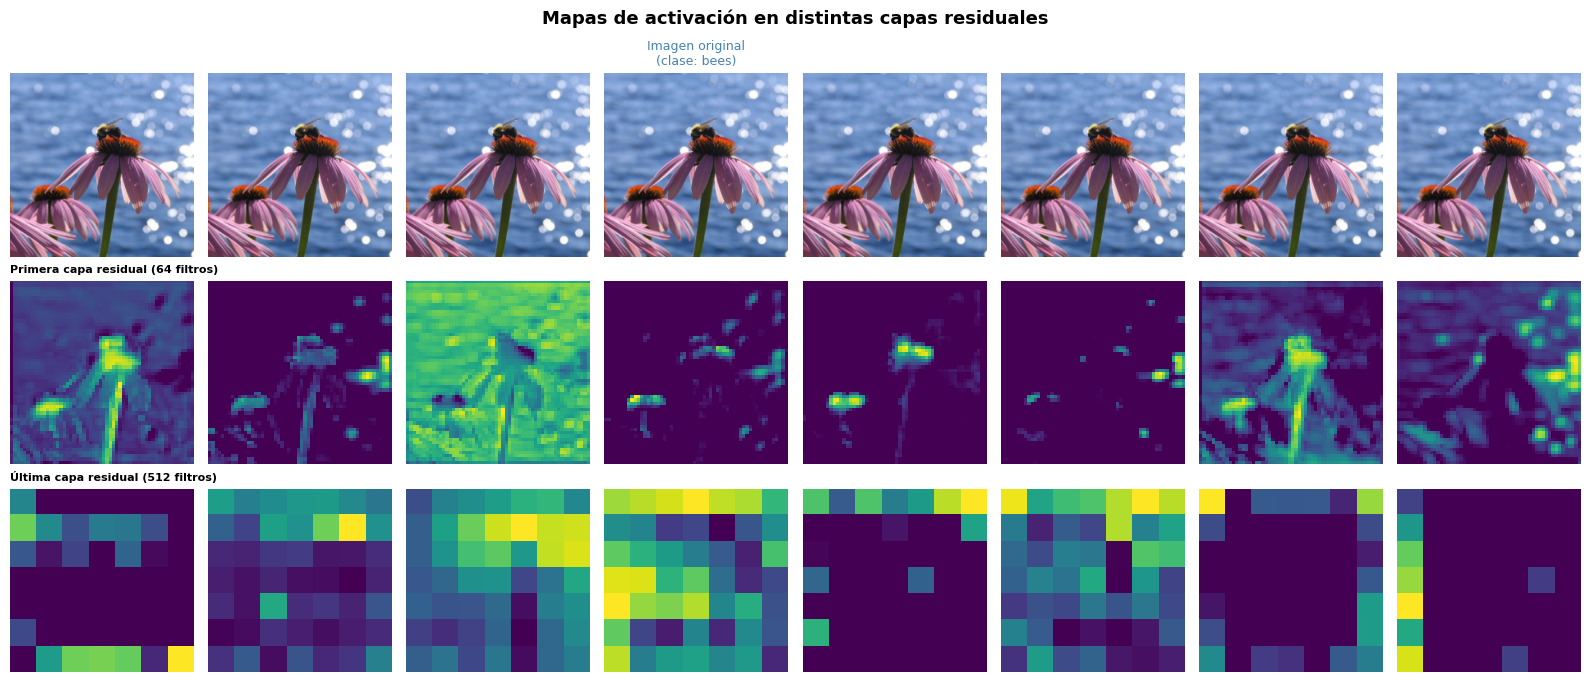

In [15]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

# Cargamos una imagen del conjunto de prueba
mean_t = torch.tensor([0.485, 0.456, 0.406])
std_t  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    return (tensor * std_t[:, None, None] + mean_t[:, None, None]).clamp(0, 1)

# Capturamos activaciones con un hook
activations = {}

def make_hook(name):
    def hook(module, input, output):
        activations[name] = output.detach().cpu()
    return hook

# Registramos hooks en la primera y última capa residual
first_residual = model_scratch.resnet[4]   # Primer ResidualUnit
last_residual  = model_scratch.resnet[-4]  # Último ResidualUnit

h1 = first_residual.register_forward_hook(make_hook("primera_residual"))
h2 = last_residual.register_forward_hook(make_hook("ultima_residual"))

# Pasamos una imagen
model_scratch.eval()
sample_img, sample_label = test_set[0]
sample_tensor = sample_img.unsqueeze(0).to(device)

with torch.no_grad():
    _ = model_scratch(sample_tensor)

h1.remove()
h2.remove()

# Visualizamos
fig, axes = plt.subplots(3, 8, figsize=(16, 7))
fig.suptitle("Mapas de activación en distintas capas residuales",
             fontsize=13, fontweight="bold")

# Fila 0: imagen original
img_np = denormalize(sample_img).permute(1, 2, 0).numpy()
for ax in axes[0]:
    ax.imshow(img_np)
    ax.axis("off")
axes[0][3].set_title(f"Imagen original\n(clase: {class_names[sample_label]})",
                     fontsize=9, color="steelblue")

# Filas 1 y 2: activaciones
for row_idx, (key, title) in enumerate([
    ("primera_residual", "Primera capa residual (64 filtros)"),
    ("ultima_residual",  "Última capa residual (512 filtros)")
]):
    act = activations[key][0]  # (C, H, W)
    indices = torch.randperm(act.shape[0])[:8]
    for col_idx, ch in enumerate(indices):
        ax = axes[row_idx + 1][col_idx]
        ax.imshow(act[ch].numpy(), cmap="viridis")
        ax.axis("off")
        if col_idx == 0:
            ax.set_title(title, fontsize=8, fontweight="bold", loc="left")

plt.tight_layout()
plt.show()

---

### <font color="blue">**Ejercicio 2.** Interpretación de los mapas de activación</font>

<font color="green">1. Observa los mapas de la primera capa residual vs. la última. ¿Qué diferencias visuales notas? ¿A qué tipo de características (bordes, texturas, partes semánticas) crees que responde cada etapa de la red?</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
La primera capa residual produce mapas con resolución espacial alta (la imagen sigue siendo «legible»), y los activaciones tienden a resaltar bordes, contornos y gradientes de color. Son detectores de bajo nivel: responden a cambios locales de intensidad, independientemente del contenido semántico.

La última capa residual produce mapas de resolución mucho menor (por los strides acumulados) y más abstractos: no es posible reconocer la imagen original en ellos. Estas activaciones codifican conceptos de alto nivel como «zona del cuerpo del insecto» o «presencia de antenas», aunque visualmente no sean interpretables directamente por humanos.
</p>
</details>



## 11. Comparación: ResNet-34 desde cero vs. Transfer Learning

Resumimos visualmente el contraste entre ambos enfoques. Completa la celda con los valores que obtuviste en la actividad anterior de Transfer Learning.

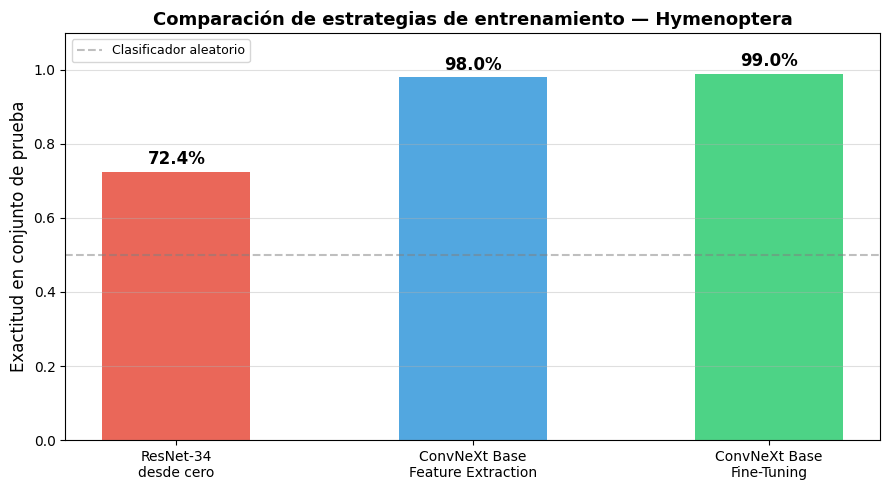

In [18]:
# ====================================================================
# Reemplaza estos valores con los obtenidos en la actividad anterior
acc_feature_extraction = 0.98  # exactitud solo con cabeza entrenada
acc_fine_tuning        = 0.99  # exactitud después de fine-tuning
# ====================================================================

acc_from_scratch = test_acc  # valor calculado en la sección 9

labels  = ["ResNet-34\ndesde cero", "ConvNeXt Base\nFeature Extraction", "ConvNeXt Base\nFine-Tuning"]
valores = [acc_from_scratch, acc_feature_extraction, acc_fine_tuning]
colores = ["#e74c3c", "#3498db", "#2ecc71"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(labels, valores, color=colores, alpha=0.85, width=0.5)

for bar, val in zip(bars, valores):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val*100:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 1.1)
ax.set_ylabel("Exactitud en conjunto de prueba", fontsize=12)
ax.set_title("Comparación de estrategias de entrenamiento — Hymenoptera",
             fontsize=13, fontweight="bold")
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.5, label="Clasificador aleatorio")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.show()

---

### <font color="blue">**Ejercicio 3.** Reflexión final y extensión</font>

<font color="green">1. Con base en los resultados de la comparación, ¿en qué escenarios reales recomendarías entrenar una CNN desde cero en lugar de usar Transfer Learning? Considera factores como tamaño del dataset, dominio del problema, recursos computacionales y tiempo disponible.</font>

<details>
<summary>👉 Clic para mostrar/ocultar respuesta</summary>
<p>
Entrenar desde cero es recomendable cuando:

(1) el dominio es muy diferente al de ImageNet (imágenes médicas como MRI o histología, imágenes satelitales multiespectrales, datos de audio espectrograma), donde los filtros preentrenados pueden ser menos relevantes

(2) el dataset es muy grande (cientos de miles a millones de imágenes propias), suficiente para aprender representaciones robustas

(3) se requiere una arquitectura personalizada no disponible como preentrenada

(4) hay restricciones de licencias que impiden usar modelos públicos.

</p>
</details>
